# Práctica 2 - Variables Aleatorias Continuas: Esperanza, Momentos y Varianza

**Licenciatura en Matemáticas Aplicadas, UAM-C**  
**UEA:** Probabilidad II  
**Trimestre:** 26P  
**Grupo:** CF01MA  
**Profesora** Daniela Aguirre Guerrero

---

## Objetivos

Al finalizar esta práctica, el alumnado será capaz de:

1. Calcular la **esperanza** $\mathbb{E}[X]$ de una variable aleatoria continua e interpretarla como centro de masa y como límite del promedio muestral.
2. Calcular la **varianza** y verificar la identidad $\mathrm{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$.
4. Verificar **numéricamente** (integración y simulación Monte Carlo) los resultados analíticos.
5. Aplicar estos conceptos en la resolución de problemas.

---

## 1. Marco teórico

### 1.1 Esperanza

Sea $X$ una variable aleatoria continua con función de densidad $f_X$. La **esperanza** (o valor esperado, o media) de $X$ se define como
$$\mathbb{E}[X] =\mu_{X}= \int_{-\infty}^{\infty} x\, f_X(x)\, dx,$$

Dos interpretaciones equivalentes:

- **Estadística:** límite del promedio muestral $\bar X_n \to \mathbb{E}[X]$ (Ley de los Grandes Números).
- **Física:** centro de masa (punto de equilibrio) de la densidad.

### 1.2 Esperanza de una función de $X$

Para una función $g(x)$, tenemos que
$$\mathbb{E}[g(X)] = \int_{-\infty}^{\infty} g(x)\, f_X(x)\, dx.$$

No es necesario hallar la densidad de $Y=g(X)$; basta integrar contra $f_X$.

### 1.3 Varianza

La **varianza** describe la dispersión alrededor de la media:
$$\mathrm{Var}(X) = \mathbb{E}\big[(X-\mu)^2\big] \geq 0.$$

Cumple la siguiente identidad:
$$\boxed{\;\mathrm{Var}(X) = \mathbb{E}[X^2] - \big(\mathbb{E}[X]\big)^2\;}$$

## 2. Preparación del entorno

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

# Ajustes de visualización
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

np.random.seed(42)  # reproducibilidad

## 3. La esperanza como centro de masa

La esperanza $\mathbb{E}[X]$ es el punto donde la densidad queda "en equilibrio", igual que el centro de masa de una varilla cuya densidad lineal es $f_X(x)$.

Definimos una función auxiliar que calcula la esperanza integrando numéricamente $x\,f_X(x)$ y la dibuja sobre la densidad.

In [5]:
def esperanza_numerica(X, lo, hi):
    """Calcula E[X] = ∫ x f_X(x) dx (en los intervalos: lo - hi) por integración numérica."""
    valor, _ = integrate.quad(lambda x: x * X.pdf(x), lo, hi)
    return valor


def grafica_centro_masa(X, eje_x, mu, titulo):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    pdf_vals = X.pdf(eje_x)

    # Grafica f(x)
    ax.plot(eje_x, pdf_vals, color='C0', lw=2, label=r'$f_X(x)$') 

    # Línea vertical en la media (E[X])
    ax.axvline(mu, color='C3', lw=2.5, label=fr'$\mathbb{{E}}[X] = {mu:.4f}$')

    # Triángulo (fulcro) bajo la media
    ymax = pdf_vals.max()
    tri_h = ymax * 0.06
    tri_w = (eje_x[-1] - eje_x[0]) * 0.02
    ax.fill([mu - tri_w, mu + tri_w, mu], [-tri_h, -tri_h, 0],
            color='C3', clip_on=False, zorder=5)

    # Coloca titulo, leyendas, etc.
    ax.set_title(titulo)
    ax.set_xlabel('x'); ax.set_ylabel(r'$f_X(x)$')
    ax.legend()
    ax.set_ylim(-tri_h * 1.4, ymax * 1.15)
    plt.tight_layout()
    plt.show()

### 3.1 Ejemplo: tiempo de vida de una laptop

Modelamos la vida útil (en cientos de horas) de una laptop con una variable exponencial $$f_X(x) = \begin{cases} \lambda e^{-\lambda x}, & x \geq 0 \\ 0, & x < 0 \end{cases}, \qquad F_X(x) = \begin{cases} 1 - e^{-\lambda x}, & x \geq 0 \\ 0, & x < 0 \end{cases}$$

donde $\lambda = \frac{1}{100}$.  
Teóricamente, $\mathbb{E}[X] = 1/\lambda = 100$.

E[X] teórica   (1/λ)        = 100.000000
E[X] numérica  (∫ x f dx)   = 100.000000
E[X] de scipy  (X.mean())   = 100.000000


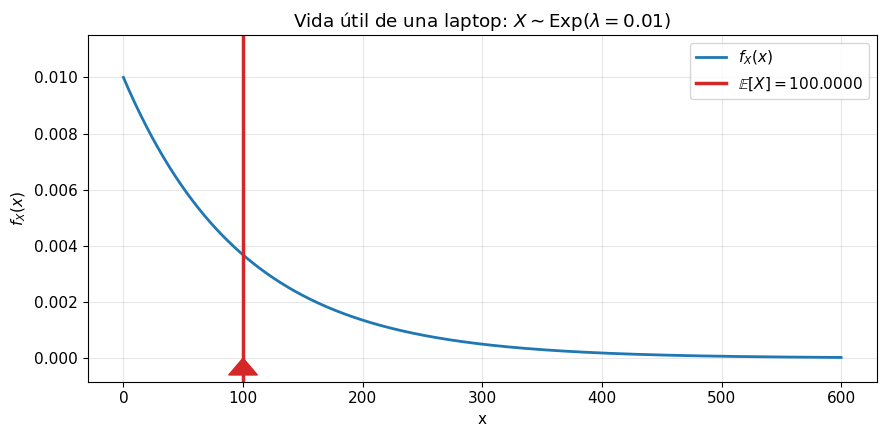

In [6]:
lam = 0.01
X = stats.expon(scale=1/lam)
eje_x = np.linspace(0, 600, 1000)

# Esperanza teórica 
mu_teorica = 1/lam
# Esperanza númerica (aproximada con scipy.integrate)
mu_numerica = esperanza_numerica(X, 0, np.inf)
# Esperanza como el promedio de un muchas observaciones de X
mu_media = X.mean()

print(f"E[X] teórica   (1/λ)        = {mu_teorica:.6f}")
print(f"E[X] numérica  (∫ x f dx)   = {mu_numerica:.6f}")
print(f"E[X] de scipy  (X.mean())   = {mu_media:.6f}")

grafica_centro_masa(X, eje_x, mu_numerica,
                    r'Vida útil de una laptop: $X \sim \mathrm{Exp}(\lambda=0.01)$')

Observa que la media (100) está **a la derecha** del grueso de la densidad: la cola larga arrastra el centro de equilibrio.

### 3.2 La esperanza como límite del promedio muestral

La Ley de los Grandes Números garantiza que el promedio de muchas observaciones converge a $\mathbb{E}[X]$. Lo verificamos simulando.

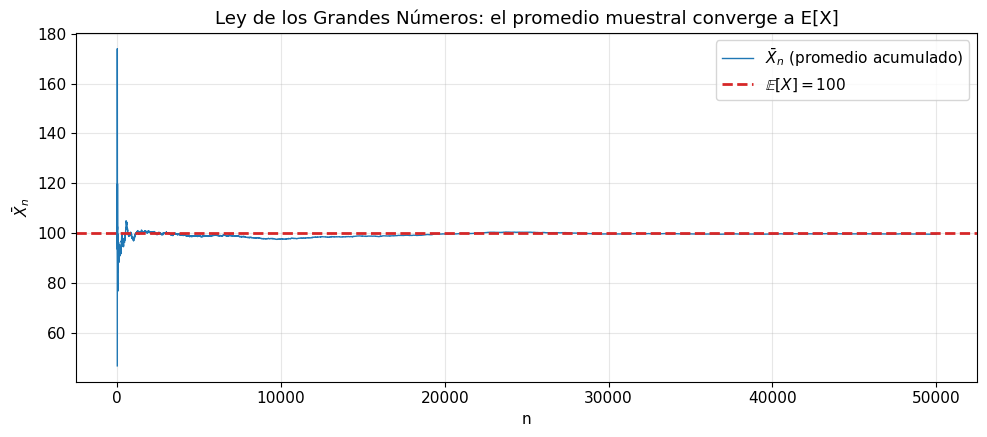

n =     10:  promedio = 102.6970
n =    100:  promedio = 91.4748
n =   1000:  promedio = 97.2506
n =  10000:  promedio = 97.7499
n =  50000:  promedio = 99.6117


In [7]:
n_max = 50000

# Tomamos 50000 observaciones de X
# La muestra n tiene n observaciones de X
muestra = X.rvs(size=n_max)

# Calculamos el promedio de cada muestra
promedios = np.cumsum(muestra) / np.arange(1, n_max + 1)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(promedios, color='C0', lw=1, label=r'$\bar{X}_n$ (promedio acumulado)')
ax.axhline(mu_teorica, color='C3', lw=2, ls='--',
           label=fr'$\mathbb{{E}}[X] = {mu_teorica:.0f}$')
#ax.set_xscale('log')
#ax.set_xlabel('n (escala log)')
ax.set_xlabel('n')
ax.set_ylabel(r'$\bar{X}_n$')
ax.set_title('Ley de los Grandes Números: el promedio muestral converge a E[X]')
ax.legend()
plt.tight_layout()
plt.show()

for n in [10, 100, 1000, 10000, 50000]:
    print(f"n = {n:>6}:  promedio = {muestra[:n].mean():.4f}")

## 4. Varianza: la identidad fundamental

Verificamos numéricamente la identidad
$$\mathrm{Var}(X) = \mathbb{E}[X^2] - \big(\mathbb{E}[X]\big)^2$$
de **dos maneras**: aproximando la integral con scipy.integrate y con la identidad.

In [8]:
def varianza_numerica(X, lo, hi, mu):
    g = lambda x: (x - mu)**2 * X.pdf(x)
    valor, _ = integrate.quad(g, lo, hi)
    return valor

In [9]:
def esperanza_x2(X, lo, hi):
    g = lambda x: x**2 * X.pdf(x)
    valor, _ = integrate.quad(g, lo, hi)
    return valor

In [10]:
# Forma 1: Numericamente, aproximando la integral
var_numerica = varianza_numerica(X, 0, np.inf, mu=mu_teorica)

# Forma 2: identidad E[X^2] - (E[X])^2
EX2 = esperanza_x2(X, 0, np.inf)
var_identidad = EX2 - mu_teorica**2

print(f"Var(X) por ∫ (x-μ)^2 f dx        = {var_numerica:.6f}")
print(f"Var(X) por E[X^2] - (E[X])^2     = {var_identidad:.6f}")
print(f"Var(X) teórica (1/λ²)            = {1/lam**2:.6f}")

Var(X) por ∫ (x-μ)^2 f dx        = 10000.000000
Var(X) por E[X^2] - (E[X])^2     = 10000.000000
Var(X) teórica (1/λ²)            = 10000.000000


### 4.1 Visualización: la desviación estándar como ancho

La desviación estándar mide cuánto se aleja típicamente $X$ de su media. La dibujamos como una banda $\mu \pm \sigma$ sobre la densidad.

In [11]:
def grafica_media_sigma(X, eje_x, mu, sigma, titulo):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    pdf_vals = X.pdf(eje_x)
    ax.plot(eje_x, pdf_vals, color='C0', lw=2, label=r'$f_X(x)$')

    # Banda mu ± sigma
    mask = (eje_x >= mu - sigma) & (eje_x <= mu + sigma)
    ax.fill_between(eje_x[mask], pdf_vals[mask], alpha=0.3, color='C2',
                    label=fr'$\mu \pm \sigma = {mu:.1f} \pm {sigma:.1f}$')

    ax.axvline(mu, color='C3', lw=2.5, label=fr'$\mu = {mu:.2f}$')
    ax.axvline(mu - sigma, color='C2', lw=1.5, ls='--')
    ax.axvline(mu + sigma, color='C2', lw=1.5, ls='--')

    ax.set_title(titulo)
    ax.set_xlabel('x'); ax.set_ylabel(r'$f_X(x)$')
    ax.legend()
    plt.tight_layout()
    plt.show()

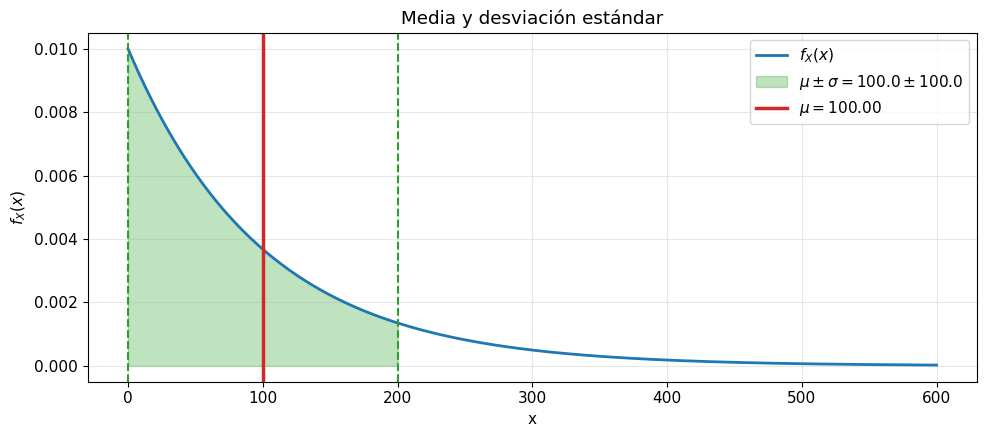

In [12]:
sigma = np.sqrt(var_numerica)
grafica_media_sigma(X, eje_x, mu_teorica, sigma,
                    r'Media y desviación estándar')

## 5. Ejercicios

Resuelve cada ejercicio en celdas nuevas, combinando código y celdas markdown con las deducciones a mano cuando se pida.

### Ejercicio 1 — Distribución uniforme

Sea $X \sim \mathcal{U}(2, 7)$.

1. Deduce analíticamente (a mano) que $\mathbb{E}[X] = \tfrac{a+b}{2}$ y $\mathrm{Var}(X) = \tfrac{(b-a)^2}{12}$.
2. Crea la variable con `stats.uniform` y calcula $\mathbb{E}[X]$ con la función `esperanza_numerica`.
3. Calcula $\mathrm{Var}(X)$ con la función `varianza_numerica` y con laidentidad $\mathbb{E}[X^2]-\mathbb{E}[X]^2$.
4. Usa ka función `grafica_media_sigma` para visualizar la esperanza y la desviación estándar.

### Ejercicio 2 — Distribución normal

Sea $X \sim \mathcal{N}(\mu=3,\ \sigma=1.5)$.

1. Calcula numéricamente la media y la varianza y compáralas con los parámetros.
2. Crea la variable con `stats.norm` y calcula $\mathbb{E}[X]$ con la función `esperanza_numerica`.
3. Calcula $\mathrm{Var}(X)$ con la función `varianza_numerica` y con laidentidad $\mathbb{E}[X^2]-\mathbb{E}[X]^2$.
4. Usa ka función `grafica_media_sigma` para visualizar la esperanza y la desviación estándar.

### Ejercicio 3 — Propiedades de la esperanza y la varianza

Sea $X \sim \mathrm{Exp}(\lambda=0.5)$ y define $Y = 3X + 2$.

1. Predice analíticamente $\mathbb{E}[Y]$ y $\mathrm{Var}(Y)$ usando $\mathbb{E}[aX+b]=a\mathbb{E}[X]+b$ y $\mathrm{Var}(aX+b)=a^2\mathrm{Var}(X)$.
2. Verifica tus predicciones con las funciones `esperanza_numerica` y `varianza_numerica`.
3. Comenta: ¿por qué la constante aditiva $b$ no afecta la varianza?

---

## Soluciones

### Ejercicio 1 — Distribución uniforme

**Parte 1. Deducción analítica.**

Para $X \sim \mathcal{U}(a,b)$ la densidad es constante en el intervalo:
$$f_X(x) = \frac{1}{b-a}, \qquad a \leq x \leq b,$$
y $f_X(x)=0$ fuera de $[a,b]$.

**Esperanza.**
$$\mathbb{E}[X] = \int_a^b x\,\frac{1}{b-a}\,dx = \frac{1}{b-a}\left[\frac{x^2}{2}\right]_a^b = \frac{b^2-a^2}{2(b-a)} = \frac{(b-a)(b+a)}{2(b-a)} = \boxed{\frac{a+b}{2}}$$

**Segundo momento.**
$$\mathbb{E}[X^2] = \int_a^b x^2\,\frac{1}{b-a}\,dx = \frac{1}{b-a}\left[\frac{x^3}{3}\right]_a^b = \frac{b^3-a^3}{3(b-a)} = \frac{a^2+ab+b^2}{3}$$

**Varianza** (con la identidad $\mathrm{Var}(X)=\mathbb{E}[X^2]-(\mathbb{E}[X])^2$):
$$\mathrm{Var}(X) = \frac{a^2+ab+b^2}{3} - \left(\frac{a+b}{2}\right)^2 = \frac{4(a^2+ab+b^2) - 3(a+b)^2}{12} = \frac{a^2-2ab+b^2}{12} = \boxed{\frac{(b-a)^2}{12}}$$

Para $a=2,\ b=7$:  $\mathbb{E}[X]=\dfrac{2+7}{2}=4.5$  y  $\mathrm{Var}(X)=\dfrac{(7-2)^2}{12}=\dfrac{25}{12}\approx 2.0833$.


**Parte 2. Creación de la variable y cálculo de $\mathbb{E}[X]$.**

`stats.uniform(loc=a, scale=b-a)` representa $\mathcal{U}(a, a+\text{scale})$, así que para $\mathcal{U}(2,7)$ usamos `loc=2, scale=5`.


In [13]:
a, b = 2, 7
U = stats.uniform(loc=a, scale=b - a)   # U(2, 7)

# Esperanza por integración numérica
mu_U_num = esperanza_numerica(U, a, b)
mu_U_teo = (a + b) / 2

print(f"E[X] analítica  (a+b)/2          = {mu_U_teo:.6f}")
print(f"E[X] numérica   (∫ x f dx)       = {mu_U_num:.6f}")
print(f"E[X] de scipy   (U.mean())       = {U.mean():.6f}")

E[X] analítica  (a+b)/2          = 4.500000
E[X] numérica   (∫ x f dx)       = 4.500000
E[X] de scipy   (U.mean())       = 4.500000


**Parte 3. Varianza por dos vías.**

In [14]:
# Vía 1: momento central de orden 2  (función varianza_numerica del notebook)
var_U_central = varianza_numerica(U, a, b, mu=mu_U_num)

# Vía 2: identidad E[X^2] - (E[X])^2
EX2_U = esperanza_x2(U, a, b)
var_U_identidad = EX2_U - mu_U_num**2

# Valor analítico
var_U_teo = (b - a)**2 / 12

print(f"Var(X) por ∫ (x-μ)^2 f dx        = {var_U_central:.6f}")
print(f"Var(X) por E[X^2] - (E[X])^2     = {var_U_identidad:.6f}")
print(f"Var(X) analítica (b-a)²/12       = {var_U_teo:.6f}")
print(f"Var(X) de scipy  (U.var())       = {U.var():.6f}")

Var(X) por ∫ (x-μ)^2 f dx        = 2.083333
Var(X) por E[X^2] - (E[X])^2     = 2.083333
Var(X) analítica (b-a)²/12       = 2.083333
Var(X) de scipy  (U.var())       = 2.083333


**Parte 4. Visualización de la esperanza y la desviación estándar.**

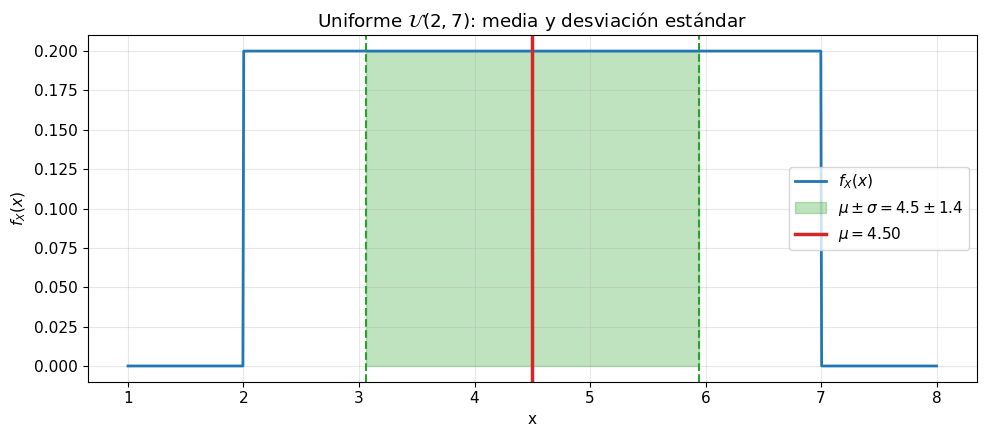

In [15]:
sigma_U = np.sqrt(var_U_central)
eje_U = np.linspace(a - 1, b + 1, 1000)

grafica_media_sigma(U, eje_U, mu_U_num, sigma_U,
                    r'Uniforme $\mathcal{U}(2,7)$: media y desviación estándar')

**Conclusión del Ejercicio 1.** Las dos vías numéricas reproducen el valor analítico $\mathbb{E}[X]=4.5$ y $\mathrm{Var}(X)=25/12\approx 2.0833$. En la gráfica la media queda exactamente en el centro del intervalo (la uniforme es simétrica) y la banda $\mu\pm\sigma$ cubre una parte central del soporte.

### Ejercicio 2 — Distribución normal

Sea $X \sim \mathcal{N}(\mu=3,\ \sigma=1.5)$.

**Parte 1 y 2. Creación de la variable y cálculo numérico de media y varianza.**

En `scipy`, `stats.norm(loc=μ, scale=σ)` recibe la **desviación estándar** como `scale` (no la varianza). Para la normal el soporte es todo $\mathbb{R}$, así que integramos sobre un rango amplio alrededor de la media (p. ej. $\mu \pm 10\sigma$), donde la densidad es despreciable en los extremos.


In [16]:
mu_par, sigma_par = 3, 1.5
Nrm = stats.norm(loc=mu_par, scale=sigma_par)

# Límites de integración: la normal decae muy rápido, ±10σ es más que suficiente
lo_N, hi_N = mu_par - 10*sigma_par, mu_par + 10*sigma_par

mu_N_num = esperanza_numerica(Nrm, lo_N, hi_N)
var_N_num = varianza_numerica(Nrm, lo_N, hi_N, mu=mu_N_num)

print(f"Media:    numérica = {mu_N_num:.6f}   |  parámetro μ      = {mu_par}")
print(f"Varianza: numérica = {var_N_num:.6f}  |  parámetro σ²     = {sigma_par**2}")
print(f"Desv. estándar:      numérica = {np.sqrt(var_N_num):.6f}  |  parámetro σ = {sigma_par}")

Media:    numérica = 3.000000   |  parámetro μ      = 3
Varianza: numérica = 2.250000  |  parámetro σ²     = 2.25
Desv. estándar:      numérica = 1.500000  |  parámetro σ = 1.5


**Parte 3. Varianza por las dos vías.**

In [17]:
# Vía 1: momento central de orden 2
var_N_central = varianza_numerica(Nrm, lo_N, hi_N, mu=mu_N_num)

# Vía 2: identidad E[X^2] - (E[X])^2
EX2_N = esperanza_x2(Nrm, lo_N, hi_N)
var_N_identidad = EX2_N - mu_N_num**2

print(f"Var(X) por ∫ (x-μ)^2 f dx        = {var_N_central:.6f}")
print(f"Var(X) por E[X^2] - (E[X])^2     = {var_N_identidad:.6f}")
print(f"Var(X) teórica (σ²)              = {sigma_par**2:.6f}")
print(f"Var(X) de scipy (Nrm.var())      = {Nrm.var():.6f}")

Var(X) por ∫ (x-μ)^2 f dx        = 2.250000
Var(X) por E[X^2] - (E[X])^2     = 2.250000
Var(X) teórica (σ²)              = 2.250000
Var(X) de scipy (Nrm.var())      = 2.250000


**Parte 4. Visualización de la esperanza y la desviación estándar.**

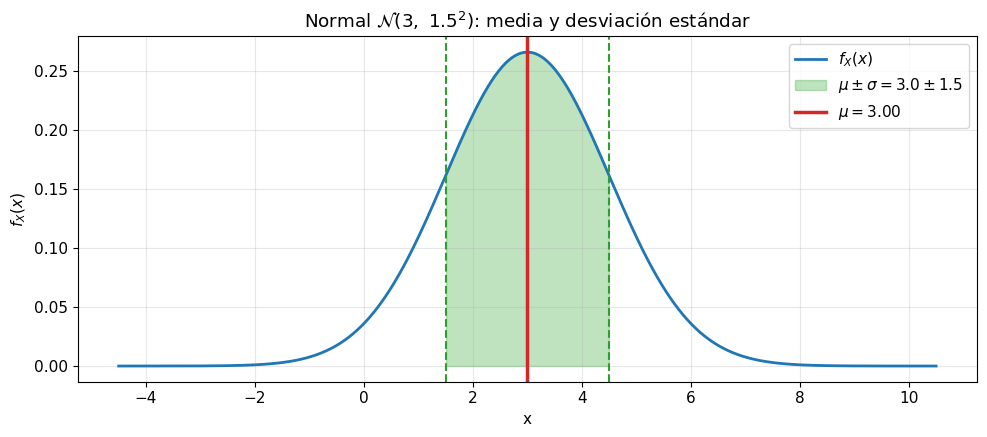

P(μ-σ ≤ X ≤ μ+σ) = 0.6827  (regla empírica: ≈ 0.6827)


In [18]:
sigma_N = np.sqrt(var_N_central)
eje_N = np.linspace(mu_par - 5*sigma_par, mu_par + 5*sigma_par, 1000)

grafica_media_sigma(Nrm, eje_N, mu_N_num, sigma_N,
                    r'Normal $\mathcal{N}(3,\ 1.5^2)$: media y desviación estándar')

# Verificación adicional: P(μ-σ ≤ X ≤ μ+σ) ≈ 0.68 (regla empírica)
p_1sigma = Nrm.cdf(mu_par + sigma_par) - Nrm.cdf(mu_par - sigma_par)
print(f"P(μ-σ ≤ X ≤ μ+σ) = {p_1sigma:.4f}  (regla empírica: ≈ 0.6827)")

**Conclusión del Ejercicio 2.** Los cálculos numéricos recuperan exactamente los parámetros: media $=3$ y varianza $=\sigma^2=2.25$. Las dos vías para la varianza coinciden. La normal es simétrica, por lo que la media coincide con el centro y el pico de la densidad; además se confirma la *regla empírica*: cerca del 68 % de la probabilidad cae dentro de $\mu\pm\sigma$.

### Ejercicio 3 — Propiedades de la esperanza y la varianza

Sea $X \sim \mathrm{Exp}(\lambda=0.5)$ y $Y = 3X + 2$.

**Parte 1. Predicción analítica.**

Para la exponencial con $\lambda=0.5$:
$$\mathbb{E}[X] = \frac{1}{\lambda} = \frac{1}{0.5} = 2, \qquad \mathrm{Var}(X) = \frac{1}{\lambda^2} = \frac{1}{0.25} = 4.$$

Aplicando las propiedades de transformaciones lineales $Y=aX+b$ con $a=3,\ b=2$:

$$\mathbb{E}[Y] = a\,\mathbb{E}[X] + b = 3\cdot 2 + 2 = \boxed{8}$$

$$\mathrm{Var}(Y) = a^2\,\mathrm{Var}(X) = 3^2 \cdot 4 = \boxed{36}$$

$$\sigma_Y = \sqrt{\mathrm{Var}(Y)} = 6$$


**Parte 2. Verificación numérica.**

Para verificar con `esperanza_numerica` y `varianza_numerica` necesitamos un objeto que represente $Y=3X+2$. La forma más limpia es notar que una transformación lineal de una exponencial vuelve a ser una exponencial *desplazada y escalada*, que en `scipy` se obtiene con los parámetros `loc` y `scale`:

- $X \sim \mathrm{Exp}(\lambda=0.5)$ se crea como `stats.expon(scale=1/0.5)`.
- $Y = 3X + 2$ se obtiene escalando por 3 y desplazando por 2: `stats.expon(loc=2, scale=3*(1/0.5))`.

También verificamos con simulación Monte Carlo, que no depende de conocer la forma de $Y$.


In [19]:
lam3 = 0.5
Xexp = stats.expon(scale=1/lam3)            # X ~ Exp(0.5)

# Predicciones analíticas
EX_teo  = 1/lam3
VarX_teo = 1/lam3**2
EY_teo   = 3*EX_teo + 2
VarY_teo = 3**2 * VarX_teo

# --- Verificación de X ---
EX_num  = esperanza_numerica(Xexp, 0, np.inf)
VarX_num = varianza_numerica(Xexp, 0, np.inf, mu=EX_num)
print("Variable X ~ Exp(0.5)")
print(f"  E[X]:   analítica = {EX_teo:.4f}   numérica = {EX_num:.4f}")
print(f"  Var(X): analítica = {VarX_teo:.4f}   numérica = {VarX_num:.4f}")

# --- Verificación de Y = 3X + 2 ---
# Y es una exponencial desplazada (loc=2) y escalada (scale = 3 * 1/lam)
Yexp = stats.expon(loc=2, scale=3*(1/lam3))
lo_Y, hi_Y = 2, np.inf                      # soporte de Y empieza en loc=2

EY_num  = esperanza_numerica(Yexp, lo_Y, hi_Y)
VarY_num = varianza_numerica(Yexp, lo_Y, hi_Y, mu=EY_num)
print("\nVariable Y = 3X + 2")
print(f"  E[Y]:   predicción = {EY_teo:.4f}   numérica = {EY_num:.4f}")
print(f"  Var(Y): predicción = {VarY_teo:.4f}   numérica = {VarY_num:.4f}")

Variable X ~ Exp(0.5)
  E[X]:   analítica = 2.0000   numérica = 2.0000
  Var(X): analítica = 4.0000   numérica = 4.0000

Variable Y = 3X + 2
  E[Y]:   predicción = 8.0000   numérica = 8.0000
  Var(Y): predicción = 36.0000   numérica = 36.0000


In [20]:
lam3 = 0.5
Xexp = stats.expon(scale=1/lam3)            # X ~ Exp(0.5)

# --- Verificación de X ---
EX_num  = esperanza_numerica(Xexp, 0, np.inf)
VarX_num = varianza_numerica(Xexp, 0, np.inf, mu=EX_num)
print("Variable X ~ Exp(0.5)")
print(f"  E[X]:   analítica = {EX_teo:.4f}   numérica = {EX_num:.4f}")
print(f"  Var(X): analítica = {VarX_teo:.4f}   numérica = {VarX_num:.4f}")

# --- Verificación de Y = 3X + 2 ---
# Y es una exponencial desplazada (loc=2) y escalada (scale = 3 * 1/lam)
Yexp = stats.expon(loc=2, scale=3*(1/lam3))
lo_Y, hi_Y = 2, np.inf                      # soporte de Y empieza en loc=2

# --- Verificación de la identidad
EY_num  = esperanza_numerica(Yexp, lo_Y, hi_Y)
VarY_num = varianza_numerica(Yexp, lo_Y, hi_Y, mu=EY_num)
EY_id = 3*EX_num + 2
print("\nVariable Y = 3X + 2")
print(f"  E[Y]:   predicción = {EY_teo:.4f}   numérica = {EY_num:.4f}   identidad = {EY_id:.4f}")
print(f"  Var(Y): predicción = {VarY_teo:.4f}   numérica = {VarY_num:.4f}")

EY_id = 3*EX_num + 2


Variable X ~ Exp(0.5)
  E[X]:   analítica = 2.0000   numérica = 2.0000
  Var(X): analítica = 4.0000   numérica = 4.0000

Variable Y = 3X + 2
  E[Y]:   predicción = 8.0000   numérica = 8.0000   identidad = 8.0000
  Var(Y): predicción = 36.0000   numérica = 36.0000


In [21]:
# Verificación independiente por Monte Carlo (no usa la forma de Y)
np.random.seed(0)
muestra_X = Xexp.rvs(size=1_000_000)
muestra_Y = 3*muestra_X + 2

print("Monte Carlo (N = 1,000,000)")
print(f"  E[Y]   ≈ {muestra_Y.mean():.4f}   (predicción: {EY_teo})")
print(f"  Var(Y) ≈ {muestra_Y.var():.4f}   (predicción: {VarY_teo})")

Monte Carlo (N = 1,000,000)
  E[Y]   ≈ 8.0069   (predicción: 8.0)
  Var(Y) ≈ 36.0774   (predicción: 36.0)


**Parte 3. ¿Por qué la constante aditiva $b$ no afecta la varianza?**

La varianza mide la **dispersión alrededor de la media**, es decir, qué tan separados están los valores entre sí, no *dónde* están ubicados. Sumar una constante $b$ a todos los valores **traslada** la distribución completa (incluida su media) la misma cantidad hacia la derecha, pero **las distancias relativas entre los puntos no cambian**: cada valor $x_i$ se aleja de la media exactamente lo mismo que antes.

Formalmente, si $Y = X + b$ entonces $\mu_Y = \mu_X + b$, y al calcular la varianza:
$$\mathrm{Var}(Y) = \mathbb{E}\big[(Y-\mu_Y)^2\big] = \mathbb{E}\big[((X+b)-(\mu_X+b))^2\big] = \mathbb{E}\big[(X-\mu_X)^2\big] = \mathrm{Var}(X).$$

La constante $b$ se cancela porque aparece sumada tanto en $Y$ como en $\mu_Y$. En cambio, el factor multiplicativo $a$ **sí** estira o comprime las distancias a la media, y por eso aparece al cuadrado: $\mathrm{Var}(aX+b)=a^2\,\mathrm{Var}(X)$.

Con la analogía del balancín: trasladar la tabla entera no cambia cómo está repartida la masa respecto a su propio centro; solo cambia dónde está el centro.

---

## Resumen de las soluciones

| Ejercicio | Resultado principal |
|---|---|
| 1. Uniforme $\mathcal{U}(2,7)$ | $\mathbb{E}[X]=4.5$, $\mathrm{Var}(X)=25/12\approx 2.083$ |
| 2. Normal $\mathcal{N}(3,1.5^2)$ | media $=3$, varianza $=2.25$; ≈68 % en $\mu\pm\sigma$ |
| 3. $Y=3X+2$ con $X\sim\mathrm{Exp}(0.5)$ | $\mathbb{E}[Y]=8$, $\mathrm{Var}(Y)=36$ |

En los tres casos los valores analíticos, la integración numérica y (cuando aplica) la simulación Monte Carlo coinciden, confirmando tanto las fórmulas como la identidad $\mathrm{Var}(X)=\mathbb{E}[X^2]-(\mathbb{E}[X])^2$ y las propiedades de las transformaciones lineales.